<a href="https://colab.research.google.com/github/shadmanr1/Milestone_1/blob/main/Week_5_Notebook_Shadman_Raakin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import (LinearRegression,Ridge,Lasso,ElasticNet)
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (mean_squared_error,mean_absolute_error,r2_score)
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.svm import SVC

# Dataset: Movie Box office (2000-2024)
General overview of the dataset is that it provides a detailed analysis of global box office performance from 2000 to 2024. It includes information on movies released during this period, covering key metrics such as release dates, genres, production budgets, worldwide gross, and more. The dataset aims to assist researchers, data scientists, and movie enthusiasts in exploring trends in the film industry, analyzing profitability, and understanding audience preferences over the years.
https://www.kaggle.com/datasets/aditya126/movies-box-office-dataset-2000-2024?select=enhanced_box_office_data%282000-2024%29u.csv

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving enhanced_box_office_data(2000-2024)u.csv to enhanced_box_office_data(2000-2024)u.csv


In [ ]:
df = pd.read_csv("enhanced_box_office_data(2000-2024)u.csv")
df.head()

,Rank,Release Group,$Worldwide,$Domestic,Domestic %,$Foreign,Foreign %,Year,Genres,Rating,Vote_Count,Original_Language,Production_Countries
0,1,Mission: Impossible II,546388108.0,215409889.0,39.4,330978219.0,60.6,2000,"Adventure, Action, Thriller",6.126/10,6741.0,en,United States of America
1,2,Gladiator,460583960.0,187705427.0,40.8,272878533.0,59.2,2000,"Action, Drama, Adventure",8.217/10,19032.0,en,"United Kingdom, United States of America"
2,3,Cast Away,429632142.0,233632142.0,54.4,196000000.0,45.6,2000,"Adventure, Drama",7.663/10,11403.0,en,United States of America
3,4,What Women Want,374111707.0,182811707.0,48.9,191300000.0,51.1,2000,"Comedy, Romance",6.45/10,3944.0,en,"United Kingdom, United States of America"
4,5,Dinosaur,349822765.0,137748063.0,39.4,212074702.0,60.6,2000,"Animation, Family, Adventure",6.544/10,2530.0,en,United States of America


In [ ]:
df = df.dropna()

In [ ]:
df['Rating'] = (df['Rating'].str.replace('/10','').astype(float))

In [ ]:
median_rev = df['$Worldwide'].median()
df['High_Revenue'] = (df['$Worldwide'] > median_rev).astype(int)

In [ ]:
X = df[['Year','Rating','Vote_Count']]
y = df['High_Revenue']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Linear kernal

In [ ]:
from sklearn.svm import SVC

linear_svm = SVC(kernel='linear')
linear_svm.fit( X_train_scaled,y_train)
pred_linear = linear_svm.predict(X_test_scaled)

RBF Kernal

In [ ]:
rbf_svm = SVC(kernel='rbf')
rbf_svm.fit(X_train_scaled,y_train)
pred_rbf = rbf_svm.predict(X_test_scaled)

Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {'C':[0.1,1,10],'gamma':['scale',0.1,1],'kernel':['rbf']}

grid = GridSearchCV(SVC(),params,cv=5)
grid.fit(X_train_scaled,y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 0.1, 1],
                         'kernel': ['rbf']})

In [ ]:
best_svm = grid.best_estimator_
pred_best = best_svm.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score,recall_score,f1_score,confusion_matrix)

In [ ]:
accuracy_score(

    y_test,

    pred_best

)

0.7697916666666667

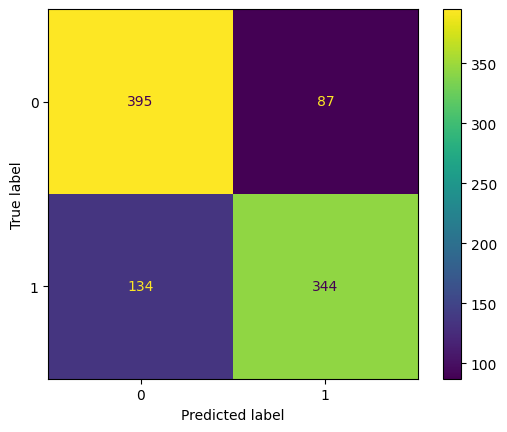

In [ ]:


ConfusionMatrixDisplay.from_predictions(

    y_test,

    pred_best

)

plt.show()

The objective of this analysis was to evaluate whether Support Vector Machines (SVMs) could accurately classify movies as having above-median or below-median worldwide revenue using features such as release year, audience rating, and vote count. Unlike logistic regression, SVMs attempt to find the optimal decision boundary that maximizes the margin between classes, potentially improving classification performance when relationships between variables are complex. Feature scaling was applied prior to training the SVM because the algorithm is highly sensitive to differences in feature magnitude. Vote Count is measured on a much larger numerical scale than Rating or Year, and without standardization it could dominate the optimization process. Standardizing the features ensures that each variable contributes more equally to the model and allows the SVM to identify a more meaningful separating boundary. Two kernel functions were evaluated during this analysis. The linear kernel assumes that the two classes can be separated using a straight decision boundary, while the radial basis function (RBF) kernel allows for nonlinear decision boundaries. The RBF kernel provides greater flexibility and can capture more complex relationships between movie characteristics and commercial success.

Hyperparameter tuning was performed using GridSearchCV to identify the optimal regularization parameter (C). Smaller values of C prioritize a larger decision margin and improved generalization, while larger values place greater emphasis on correctly classifying the training data. Selecting an appropriate value of C helps balance model complexity and overfitting.